**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 4. Benchmark policy rules: TR93, NPP and BA

The three benchmark rules of Hinterlang & Tänzer (2021), evaluated two ways: **statically**, by
plugging realised inflation and the output gap into each rule, and **dynamically**, by replacing the
policy equation of the estimated economy with the rule and feeding the historical structural shocks
back through it (the paper's Section 3.3, without the reinforcement-learning policies).

**Inputs:** `artifacts/data/`, `artifacts/linear/svar_restricted.json`.
**Outputs:** `artifacts/rules/static_prescriptions.csv`, `artifacts/rules/counterfactual_<rule>.csv`.

## Rule form

In the level form of the paper's Table 4,

$$
i_t = \alpha_0 + \beta_\pi \pi_t + \beta_y y_t, \qquad \alpha_0 = r^* - (\beta_\pi - 1)\pi^*, \qquad r^* = \pi^* = 2,
$$

which is the form of the Federal Reserve's Monetary Policy Report rules with $y_t = 2(u^* - u_t)$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import autofed as af
from autofed import linear as lin
from autofed import plots
from autofed.style import COLORS

nb = af.NotebookSession(
    "04_policy_rules", number=4, title="Benchmark policy rules: TR93, NPP and BA"
)
panel = af.load_macro_panel(nb.artifacts("data"))
cfg = panel.config
NAMES = list(af.NAMES)  # recursive ordering: y -> pi -> i
df_train, df_all = panel.train, panel.full
print(
    f"Data vintage {panel.retrieved} | training {df_train.index[0]}-{df_train.index[-1]} | "
    f"full {df_all.index[0]}-{df_all.index[-1]}"
)

RULES = list(af.REFERENCE_RULES.values())
ZLB = False  # the benchmark rules are unconstrained in the paper
COEFS = "estimated"  # "estimated": this vintage (notebook 01); "paper": H&T (2021, Table 9)
if COEFS not in {"estimated", "paper"}:
    raise ValueError(f"COEFS must be 'estimated' or 'paper', got {COEFS!r}")

Data vintage 2026-10-07 | training 1987Q3-2007Q2 | full 1987Q3-2026Q2


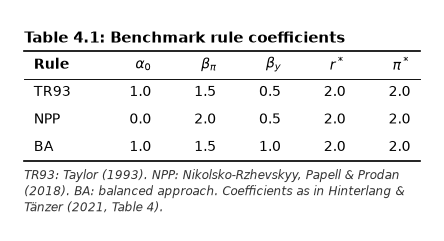

In [2]:
rule_table = pd.DataFrame({
    rule.name: {
        r"$\alpha_0$": rule.alpha0,
        r"$\beta_\pi$": rule.beta_pi,
        r"$\beta_y$": rule.beta_y,
        r"$r^*$": rule.r_star,
        r"$\pi^*$": rule.pi_star,
    }
    for rule in RULES
}).T
rule_table.index.name = "Rule"
nb.table(
    rule_table,
    "rule_coefficients",
    "Benchmark rule coefficients",
    float_format="{:.1f}",
    note=(
        "TR93: Taylor (1993). NPP: Nikolsko-Rzhevskyy, Papell & Prodan (2018). BA: balanced"
        " approach. Coefficients as in Hinterlang & Tänzer (2021, Table 4)."
    ),
)

## Static prescriptions

Each rule evaluated on realised data, quarter by quarter, with no feedback from the rule to the
economy. This shows where a rule would have set the rate given what happened; it does not show what
would have happened under the rule.

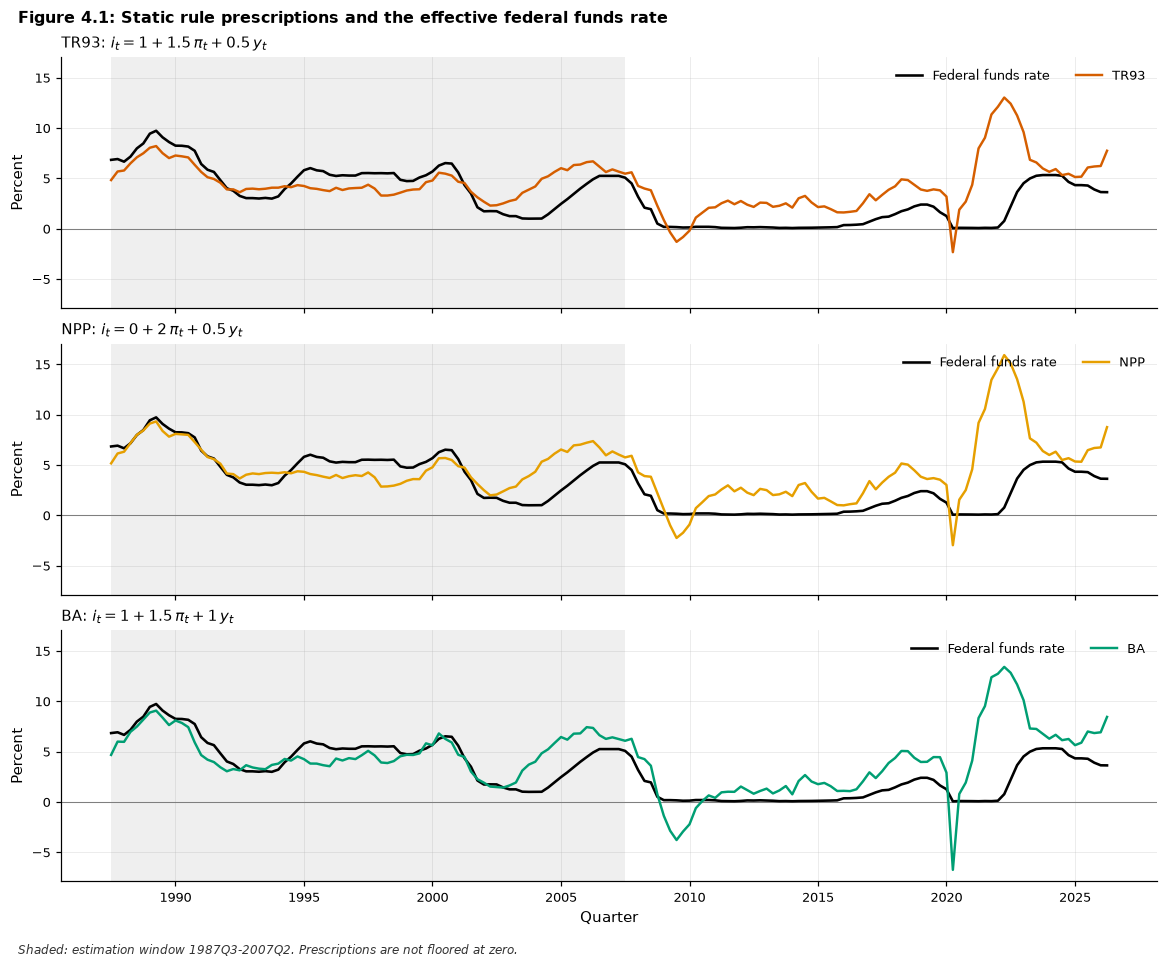

In [3]:
static = af.rules.prescriptions(df_all, RULES, zlb=ZLB)
af.save_frame(static, nb.artifacts("rules") / "static_prescriptions.csv")
x = plots.timestamps(static.index)

fig, axes = plt.subplots(len(RULES), 1, figsize=(10.5, 8.4), sharex=True, sharey=True)
for ax, rule in zip(axes, RULES):
    plots.shade_window(ax, cfg.train_start, cfg.train_end)
    ax.axhline(0.0, color=COLORS["grey"], lw=0.7)
    ax.plot(x, static["Actual"], color=COLORS["black"], lw=1.7, label="Federal funds rate")
    ax.plot(x, static[rule.name], color=plots.SERIES_COLORS[rule.name], lw=1.6, label=rule.name)
    ax.set_title(
        rf"{rule.name}: $i_t = {rule.alpha0:g} + {rule.beta_pi:g}\,\pi_t +"
        rf" {rule.beta_y:g}\,y_t$",
        loc="left",
    )
    ax.set_ylabel("Percent")
    ax.legend(loc="upper right", ncol=2)
axes[-1].set_xlabel("Quarter")
nb.figure(
    fig,
    "static_prescriptions_by_rule",
    "Static rule prescriptions and the effective federal funds rate",
    note=(
        f"Shaded: estimation window {cfg.train_start}-{cfg.train_end}. Prescriptions are not"
        " floored at zero."
    ),
)

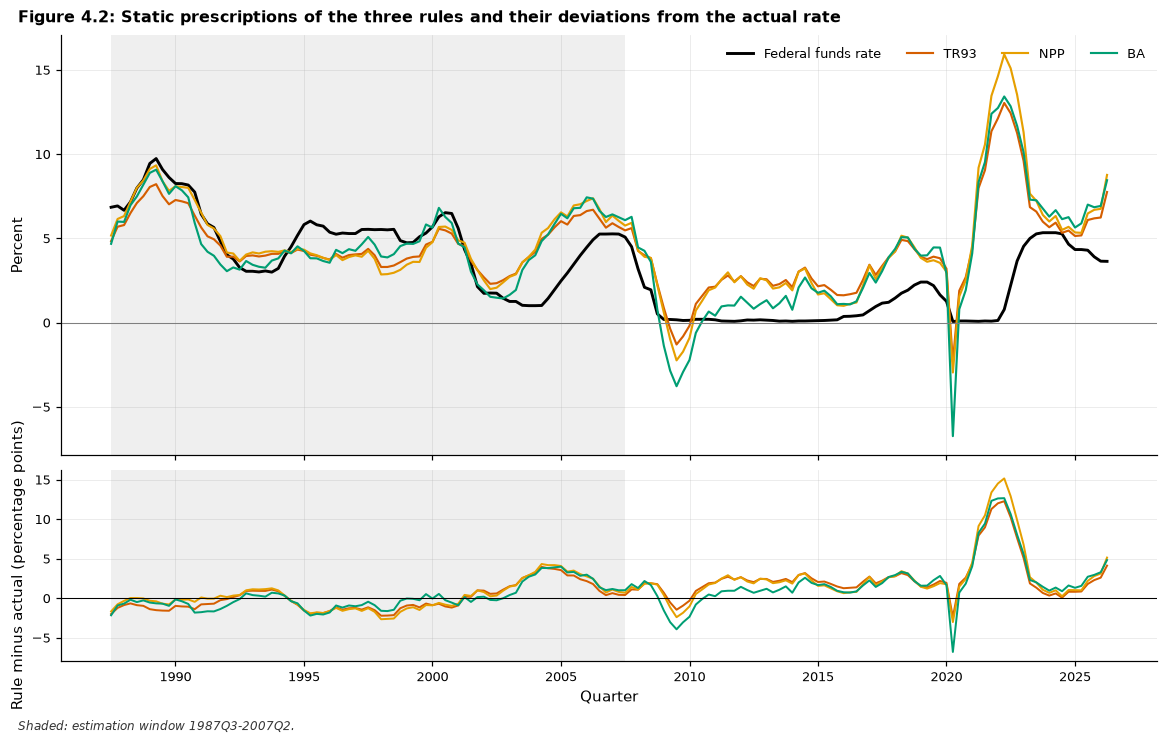

In [4]:
fig, (ax_level, ax_dev) = plt.subplots(
    2, 1, figsize=(10.5, 6.4), sharex=True, height_ratios=[2.2, 1]
)
ax_level.plot(x, static["Actual"], color=COLORS["black"], lw=1.9, label="Federal funds rate")
for rule in RULES:
    ax_level.plot(
        x, static[rule.name], color=plots.SERIES_COLORS[rule.name], lw=1.4, label=rule.name
    )
    ax_dev.plot(
        x, static[rule.name] - static["Actual"], color=plots.SERIES_COLORS[rule.name], lw=1.3
    )
ax_level.axhline(0.0, color=COLORS["grey"], lw=0.7)
ax_dev.axhline(0.0, color=COLORS["black"], lw=0.7)
ax_level.set_ylabel("Percent")
ax_dev.set_ylabel("Rule minus actual (percentage points)")
ax_dev.set_xlabel("Quarter")
ax_level.legend(loc="upper right", ncol=4)
for ax in (ax_level, ax_dev):
    plots.shade_window(ax, cfg.train_start, cfg.train_end)
nb.figure(
    fig,
    "static_prescriptions_combined",
    "Static prescriptions of the three rules and their deviations from the actual rate",
    note=f"Shaded: estimation window {cfg.train_start}-{cfg.train_end}.",
)

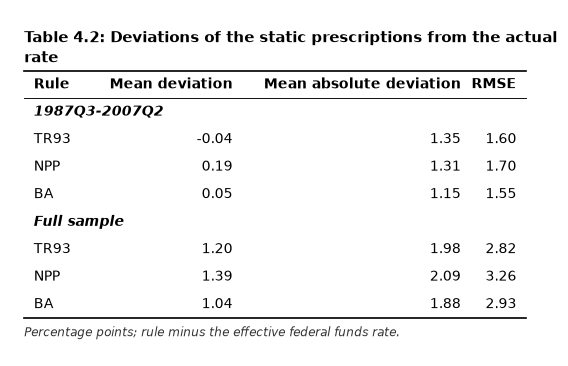

In [5]:
deviation = static[[rule.name for rule in RULES]].sub(static["Actual"], axis=0)
rows = {}
for label, part in (
    (f"{cfg.train_start}-{cfg.train_end}", deviation.loc[cfg.train_start : cfg.train_end]),
    ("Full sample", deviation),
):
    for rule in RULES:
        d = part[rule.name]
        rows[(label, rule.name)] = {
            "Mean deviation": d.mean(),
            "Mean absolute deviation": d.abs().mean(),
            "RMSE": float(np.sqrt((d**2).mean())),
        }
dev_table = pd.DataFrame.from_dict(rows, orient="index")
dev_table.index = pd.MultiIndex.from_tuples(dev_table.index, names=["Window", "Rule"])
nb.table(
    dev_table,
    "static_deviations",
    "Deviations of the static prescriptions from the actual rate",
    float_format="{:.2f}",
    note="Percentage points; rule minus the effective federal funds rate.",
)

## Dynamic counterfactual

The environment is the restricted recursive SVAR(2). With $\hat\varepsilon^y_t, \hat\varepsilon^\pi_t$ the
residuals of its two equations on realised data, and the first two quarters fixed at their realised
values,

$$
\tilde y_t = \hat f^{\,y}(\tilde z_t) + \hat\varepsilon^y_t, \qquad
\tilde\pi_t = \hat f^{\,\pi}(\tilde y_t, \tilde z_t) + \hat\varepsilon^\pi_t, \qquad
\tilde\imath_t = \alpha_0 + \beta_\pi \tilde\pi_t + \beta_y \tilde y_t,
$$

where $\tilde z_t$ collects the simulated lags. Feeding the realised funds rate through the same
recursion returns the realised data exactly, which the code asserts. Outside the estimation window the
shocks are the residuals of the fixed estimation-window coefficients.

**Closed-loop stability.** Stacking $z_t = (y_t, \pi_t, i_t)'$, each rule closes the system as
$A_0 z_t = c + A_1 z_{t-1} + A_2 z_{t-2} + \varepsilon_t$. The counterfactual is meaningful only if the
companion matrix has spectral radius below one. The net effect of the funds rate on the output gap is
close to zero in estimates of this system, so the check is worth repeating on every data vintage.

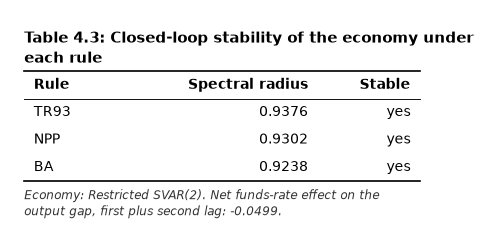

In [6]:
spec = (
    lin.RecursiveLinearSpec.load(nb.artifacts("linear") / "svar_restricted.json")
    if COEFS == "estimated"
    else lin.PAPER_TABLE9
)
shocks = lin.structural_residuals(df_all, spec)

stability = pd.DataFrame(
    {rule.name: {"Spectral radius": lin.closed_loop_radius(spec, rule)} for rule in RULES}
).T
stability["Stable"] = stability["Spectral radius"] < 1.0
stability.index.name = "Rule"
nb.table(
    stability,
    "closed_loop_stability",
    "Closed-loop stability of the economy under each rule",
    float_format="{:.4f}",
    note=(
        f"Economy: {spec.label}. Net funds-rate effect on the output gap, first plus second"
        f" lag: {spec.coef_y['i_lag1'] + spec.coef_y['i_lag2']:+.4f}."
    ),
)
unstable = stability.index[~stability["Stable"]].tolist()
if unstable:
    import warnings

    warnings.warn(
        f"closed loop is explosive under {unstable}; those paths diverge and are not"
        " interpretable",
        stacklevel=1,
    )

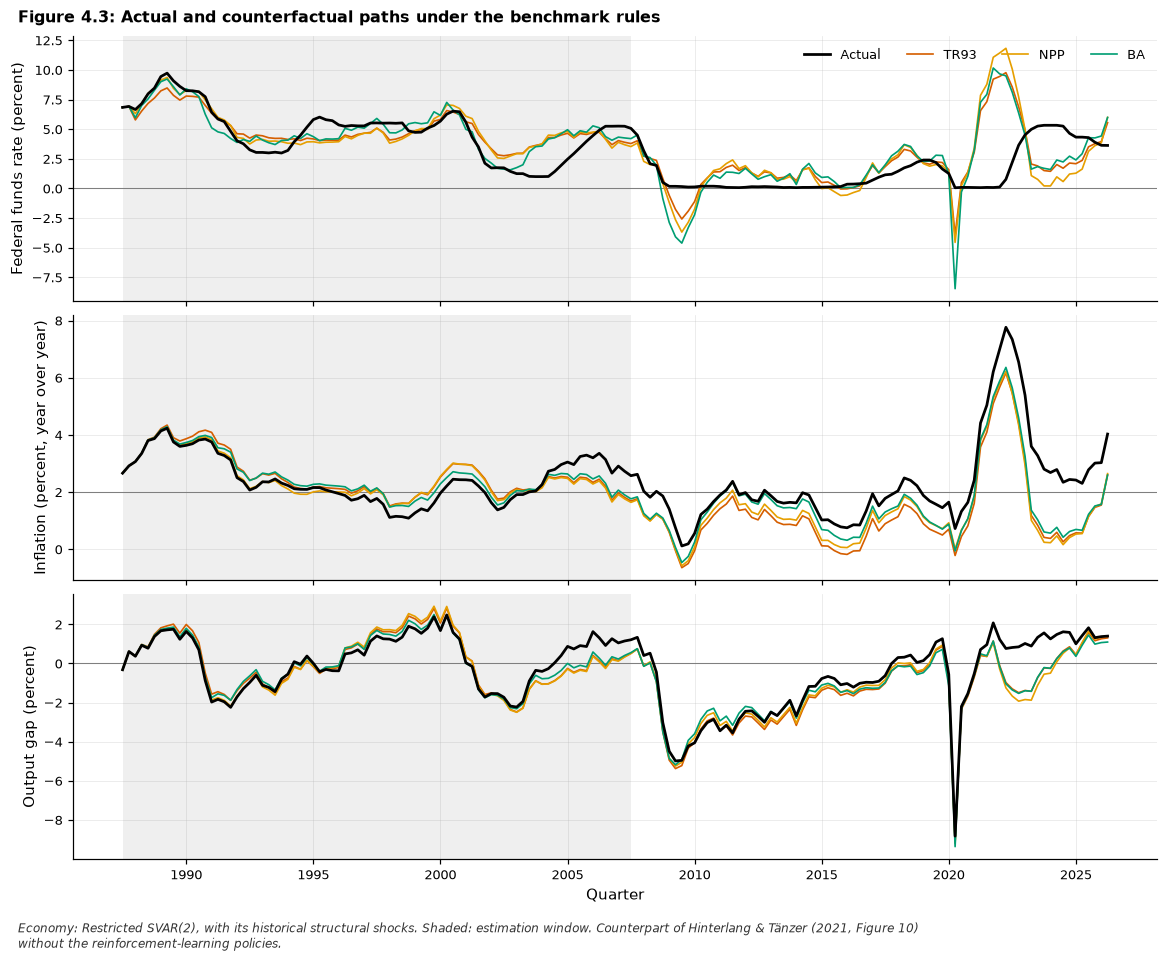

In [7]:
# Identity check: the realised policy path with the historical shocks must return the realised data.
assert np.allclose(
    lin.simulate(df_all, spec, None, residuals=shocks)[["y", "pi"]],
    df_all[["y", "pi"]],
    atol=1e-8,
)

# Rules with an explosive closed loop are left out: their paths diverge mechanically.
paths = {"Actual": df_all}
for rule in RULES:
    if stability.at[rule.name, "Stable"]:
        paths[rule.name] = lin.simulate(df_all, spec, rule, residuals=shocks, zlb=ZLB)
        af.save_frame(
            paths[rule.name], nb.artifacts("rules") / f"counterfactual_{rule.name.lower()}.csv"
        )
excluded = f" Excluded for an explosive closed loop: {', '.join(unstable)}." if unstable else ""

fig = plots.policy_paths(paths, shade=(cfg.train_start, cfg.train_end))
nb.figure(
    fig,
    "dynamic_counterfactual",
    "Actual and counterfactual paths under the benchmark rules",
    note=(
        f"Economy: {spec.label}, with its historical structural shocks. Shaded: estimation"
        " window. Counterpart of Hinterlang & Tänzer (2021, Figure 10) without the"
        " reinforcement-learning policies."
    )
    + excluded,
)

## Target deviations and loss

$\Delta^2(\pi^*, \pi_t)$ and $\Delta^2(y^*, y_t)$ are mean squared deviations from $\pi^* = 2$ and
$y^* = 0$; the loss is $0.5\,\Delta^2(\pi^*, \pi_t) + 0.5\,\Delta^2(y^*, y_t)$.

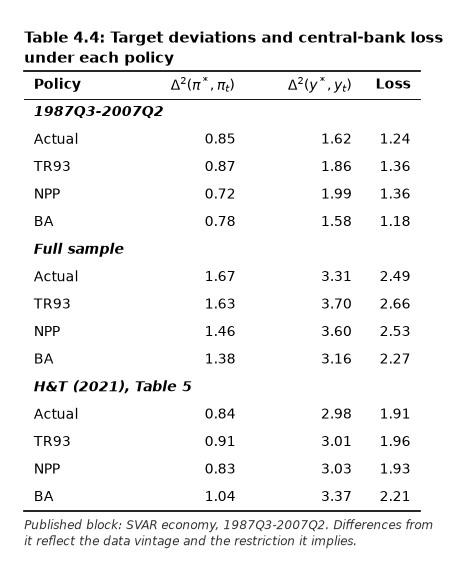

In [8]:
paper = pd.DataFrame(
    {
        "dev2 pi": [0.84, 0.91, 0.83, 1.04],
        "dev2 y": [2.98, 3.01, 3.03, 3.37],
        "Loss": [1.91, 1.96, 1.93, 2.21],
    },
    index=["Actual", "TR93", "NPP", "BA"],
)
loss = pd.concat(
    {
        f"{cfg.train_start}-{cfg.train_end}": lin.target_loss(
            paths, window=slice(cfg.train_start, cfg.train_end)
        ),
        "Full sample": lin.target_loss(paths),
        "H&T (2021), Table 5": paper,
    },
    names=["Window", "Policy"],
).rename(columns={"dev2 pi": r"$\Delta^2(\pi^*, \pi_t)$", "dev2 y": r"$\Delta^2(y^*, y_t)$"})
nb.table(
    loss,
    "counterfactual_loss",
    "Target deviations and central-bank loss under each policy",
    float_format="{:.2f}",
    note=(
        "Published block: SVAR economy, 1987Q3-2007Q2. Differences from it reflect the data"
        " vintage and the restriction it implies."
    )
    + excluded,
)

# References (APA)

## Software

1. Sunder, N. (2026). cultivars: Research-grade time series econometrics for Python (v1.0.0a1). https://pypi.org/project/cultivars/
2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942
3. The pandas development team. (2026). pandas-dev/pandas: Pandas. Zenodo. https://doi.org/10.5281/zenodo.18675244
4. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2
5. Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., … SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
6. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python. Zenodo. https://doi.org/10.5281/zenodo.17595503
7. Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. In *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011
8. Kluyver, T., Ragan-Kelley, B., Pérez, F., Granger, B., Bussonnier, M., Frederic, J., Kelley, K., Hamrick, J., Grout, J., Corlay, S., Ivanov, P., Avila, D., Abdalla, S., Willing, C., & Jupyter Development Team. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. In *Positioning and Power in Academic Publishing: Players, Agents and Agendas* (pp. 87–90). IOS Press. https://doi.org/10.3233/978-1-61499-649-1-87
9. Python Software Foundation. (2025). Python (Version 3.13) [Computer software]. https://www.python.org/

## Papers & Books

1. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *SSRN*. https://doi.org/10.2139/ssrn.4013384
2. Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1–48. https://doi.org/10.2307/1912017
3. Lütkepohl, H. (2005). *New introduction to multiple time series analysis*. Springer. https://doi.org/10.1007/3-540-27752-8
4. Clements, M. P., & Hendry, D. F. (1998). *Forecasting economic time series*. Cambridge University Press. https://doi.org/10.1017/CBO9780511599286
5. Stock, J. H., & Watson, M. W. (2007). Why has U.S. inflation become harder to forecast? *Journal of Money, Credit and Banking*, 39(s1), 3–33. https://doi.org/10.1111/j.1538-4616.2007.00014.x
6. Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262–302. https://doi.org/10.1016/j.red.2004.10.009
7. Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821–852. https://doi.org/10.1111/j.1467-937X.2005.00353.x
8. Hamilton, J. D. (1994). *Time series analysis*. Princeton University Press.
9. Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545–1578. https://doi.org/10.1111/j.1468-0262.2006.00718.x
10. Carter, C. K., & Kohn, R. (1994). On Gibbs sampling for state space models. *Biometrika*, 81(3), 541–553. https://doi.org/10.1093/biomet/81.3.541
11. Kim, S., Shephard, N., & Chib, S. (1998). Stochastic volatility: Likelihood inference and comparison with ARCH models. *Review of Economic Studies*, 65(3), 361–393. https://doi.org/10.1111/1467-937X.00050
12. Kim, C.-J., & Nelson, C. R. (1999). *State-space models with regime switching: Classical and Gibbs-sampling approaches with applications*. MIT Press.
13. Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263. https://doi.org/10.1080/07350015.1995.10524599
14. Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281–291. https://doi.org/10.1016/S0169-2070(96)00719-4
15. Hansen, P. R., Lunde, A., & Nason, J. M. (2011). The model confidence set. *Econometrica*, 79(2), 453–497. https://doi.org/10.3982/ECTA5771
16. Mincer, J., & Zarnowitz, V. (1969). The evaluation of economic forecasts. In J. Mincer (Ed.), *Economic forecasts and expectations: Analysis of forecasting behavior and performance* (pp. 3–46). NBER.
17. Waggoner, D. F., & Zha, T. (1999). Conditional forecasts in dynamic multivariate models. *Review of Economics and Statistics*, 81(4), 639–651. https://doi.org/10.1162/003465399558508
18. Federal Reserve Bank of St. Louis. (n.d.). *Federal Reserve Economic Data (FRED)*. https://fred.stlouisfed.org/

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [9]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_95395/281924391.py:1: UserWarning: 04_policy_rules.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
